<a href="https://colab.research.google.com/github/janani-pb/amazonprime_content_analysis/blob/main/AMAZON_PRIME_CONTENT_TREND_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


========== AMAZON PRIME DATA ==========

  show_id   type                 title        director  \
0      s1  Movie   The Grand Seduction    Don McKellar   
1      s2  Movie  Take Care Good Night    Girish Joshi   
2      s3  Movie  Secrets of Deception     Josh Webber   
3      s4  Movie    Pink: Staying True  Sonia Anderson   
4      s5  Movie         Monster Maker    Giles Foster   

                                                cast         country  \
0     Brendan Gleeson, Taylor Kitsch, Gordon Pinsent          Canada   
1   Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar           India   
2  Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...   United States   
3  Interviews with: Pink, Adele, Beyoncé, Britney...   United States   
4  Harry Dean Stanton, Kieran O'Brien, George Cos...  United Kingdom   

       date_added  release_year rating duration                listed_in  \
0  March 30, 2021          2014    NaN  113 min            Comedy, Drama   
1  March 30, 2021       

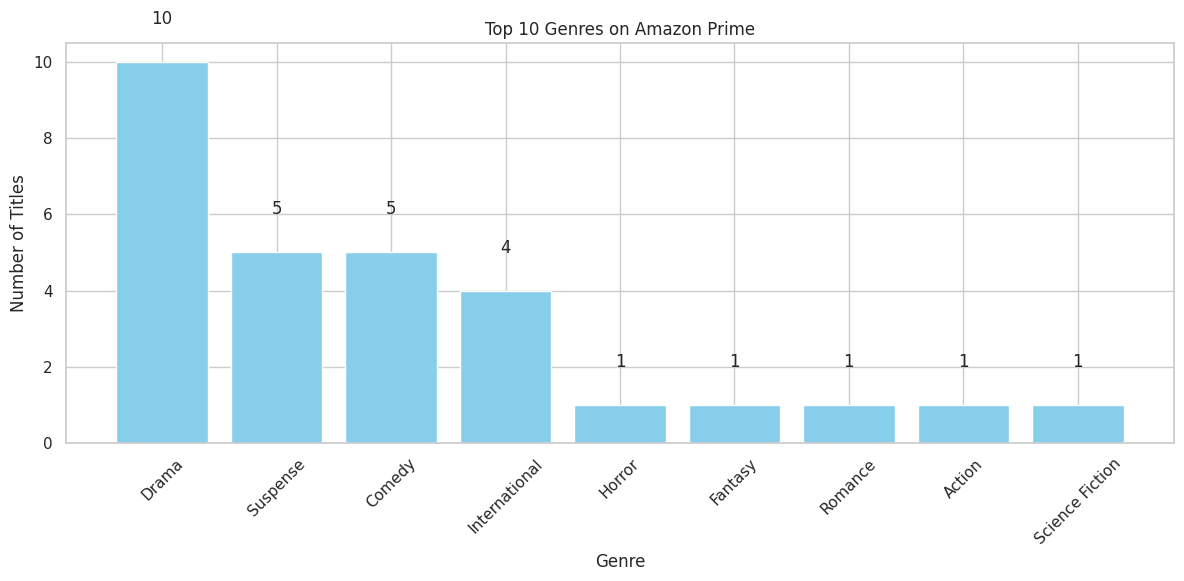


GRAPH 1 EXPLANATION:
The numbers shown on top of each bar represent
the total number of movies or TV shows available
in that genre.


========== TOP COUNTRIES ==========

country
United States                    12
India                            10
India, Sweden                     3
United States, Sweden, Norway     3
United States, Canada             1
Name: count, dtype: int64


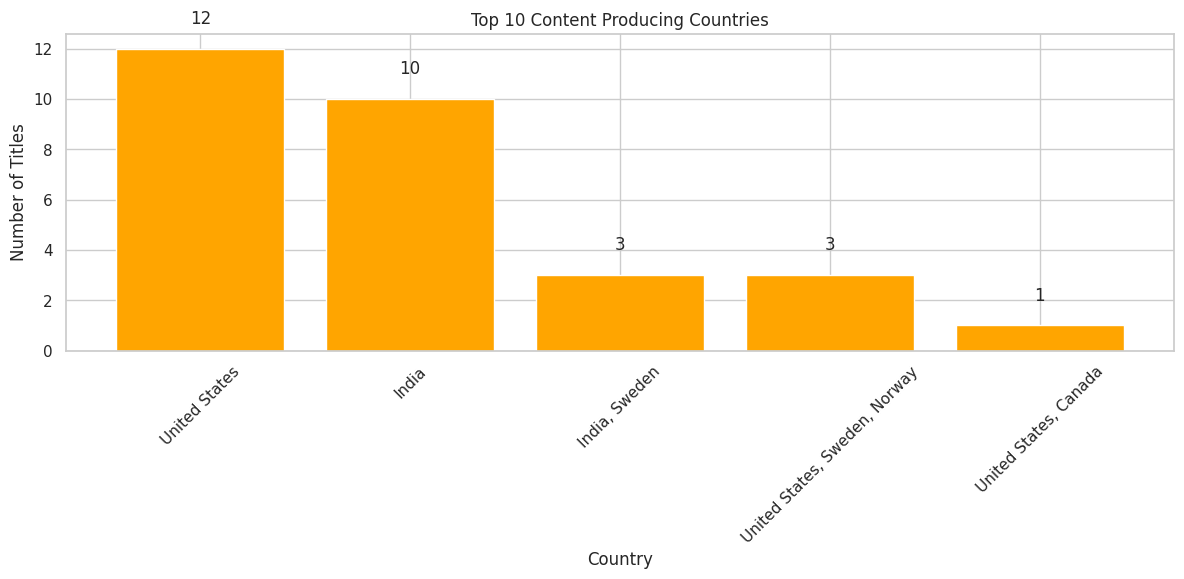


GRAPH 2 EXPLANATION:
The numbers shown on top of each bar represent
the total number of Amazon Prime titles produced
or available in each country.



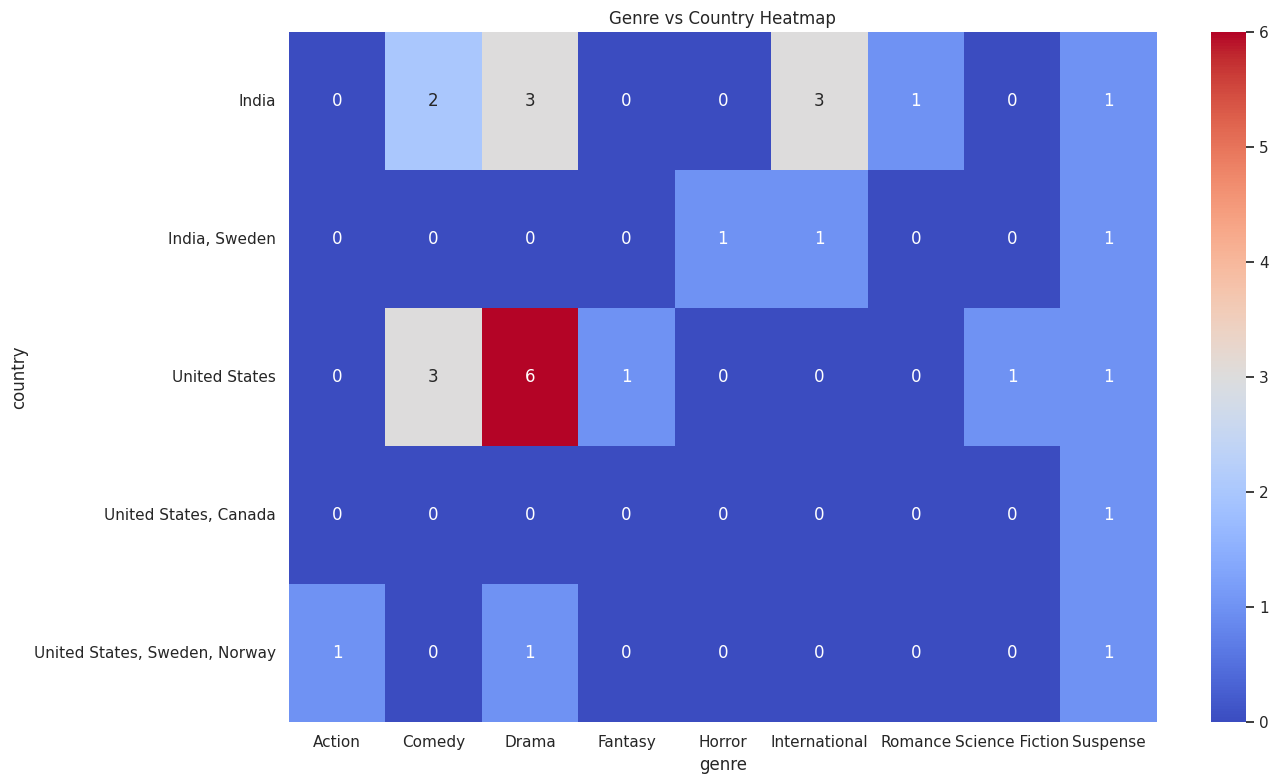


GRAPH 3 EXPLANATION:
The numbers inside the heatmap represent the count
of titles available for a particular genre in a
specific country.

Higher values indicate stronger content presence.


========== TOP RATED GENRES ==========

genre
Fantasy            8.60
Horror             8.30
International      8.15
Romance            8.10
Suspense           8.04
Comedy             8.02
Drama              7.96
Action             7.80
Science Fiction    7.60
Name: rating, dtype: float64


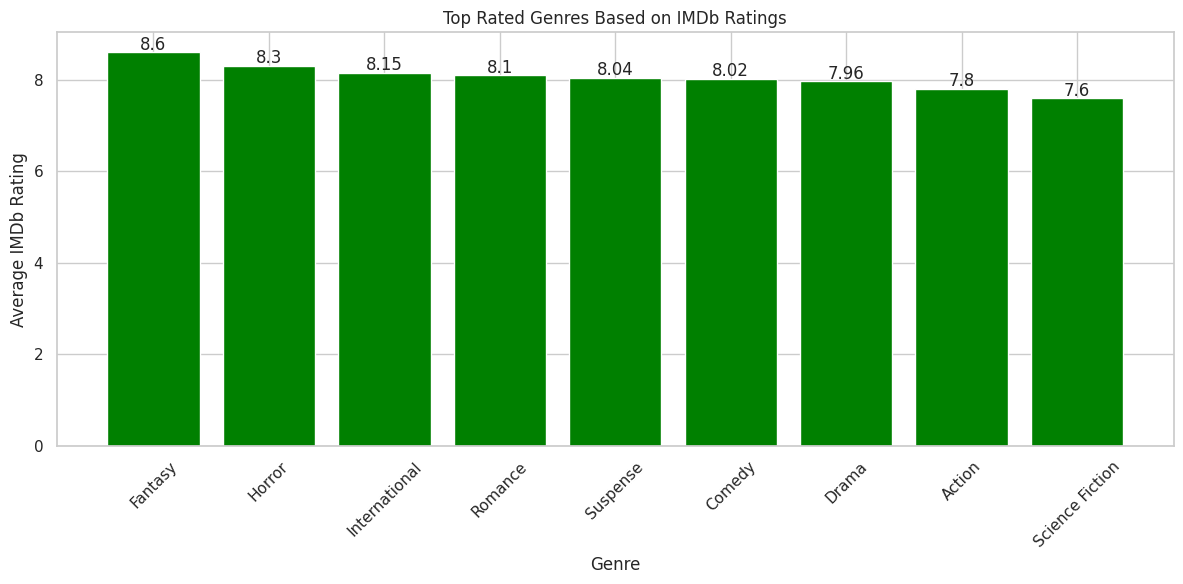


GRAPH 4 EXPLANATION:
The values on top of each bar represent the average
IMDb rating for that genre.

Higher rating values indicate better audience reception.


Database Created Successfully

========== SQL TOP GENRES ==========

             genre  total_titles
0            Drama            10
1         Suspense             5
2           Comedy             5
3    International             4
4  Science Fiction             1
5          Romance             1
6           Horror             1
7          Fantasy             1
8           Action             1

========== SQL TOP COUNTRIES ==========

                         country  total_content
0                  United States             12
1                          India             10
2  United States, Sweden, Norway              3
3                  India, Sweden              3
4          United States, Canada              1

========== SQL TOP RATED GENRES ==========

             genre  avg_rating
0          Fantasy        8.60
1 

In [1]:
# =========================================================
# AMAZON PRIME CONTENT TREND ANALYSIS
# =========================================================
# DOMAIN  : Media Streaming / Entertainment Analytics
# PROJECT : Amazon Prime Content Trend Analysis
# TOOLS   : Python, Pandas, NumPy, Matplotlib, Seaborn, SQL
# PLATFORM: Google Colab / Jupyter Notebook
# =========================================================


# =========================================================
# 1. INSTALL REQUIRED LIBRARIES
# =========================================================
# Run this only once in Google Colab

# !pip install pandas numpy matplotlib seaborn


# =========================================================
# 2. IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

sns.set(style="whitegrid")


# =========================================================
# 3. LOAD DATASETS
# =========================================================

prime_df = pd.read_csv("amazon_prime_titles.csv")
imdb_df = pd.read_csv("imdb_dataset.csv")


# =========================================================
# 4. DISPLAY DATASET INFORMATION
# =========================================================

print("\n========== AMAZON PRIME DATA ==========\n")

print(prime_df.head())

print("\nColumns in Amazon Dataset:\n")
print(prime_df.columns)

print("\n========== IMDB DATA ==========\n")

print(imdb_df.head())

print("\nColumns in IMDb Dataset:\n")
print(imdb_df.columns)


# =========================================================
# 5. DATA CLEANING
# =========================================================

# Remove missing values

prime_df = prime_df.dropna(subset=['listed_in', 'country'])

imdb_df = imdb_df.dropna(subset=['Genre', 'IMDB_Rating'])


# =========================================================
# 6. REMOVE DUPLICATE TITLES
# =========================================================

prime_df.drop_duplicates(subset=['title'], inplace=True)

imdb_df.drop_duplicates(subset=['Series_Title'], inplace=True)


# =========================================================
# 7. RENAME COLUMNS
# =========================================================

prime_df.rename(columns={
    'listed_in': 'genre',
    'director': 'prime_director'
}, inplace=True)

imdb_df.rename(columns={
    'Series_Title': 'title',
    'Genre': 'genre',
    'IMDB_Rating': 'rating',
    'Director': 'imdb_director'
}, inplace=True)


# =========================================================
# 8. CONVERT TITLES TO LOWERCASE
# =========================================================

prime_df['title'] = prime_df['title'].str.lower()

imdb_df['title'] = imdb_df['title'].str.lower()


# =========================================================
# 9. MERGE DATASETS
# =========================================================

merged_df = pd.merge(
    prime_df,
    imdb_df,
    on='title',
    how='inner'
)

print("\n========== MERGED DATA ==========\n")

print(merged_df.head())


# =========================================================
# 10. HANDLE DUPLICATE COLUMNS
# =========================================================

# Create single genre column

if 'genre_x' in merged_df.columns:
    merged_df['genre'] = merged_df['genre_x']

# Create single rating column

if 'rating_y' in merged_df.columns:
    merged_df['rating'] = merged_df['rating_y']

# Drop unwanted duplicate columns

columns_to_drop = [
    'genre_x',
    'genre_y',
    'rating_x'
]

merged_df.drop(
    columns=columns_to_drop,
    inplace=True,
    errors='ignore'
)

# Remove duplicate column names

merged_df = merged_df.loc[:, ~merged_df.columns.duplicated()]


# =========================================================
# 11. CONVERT RATING TO NUMERIC
# =========================================================

merged_df['rating'] = pd.to_numeric(
    merged_df['rating'],
    errors='coerce'
)


# =========================================================
# 12. SPLIT GENRE COLUMN
# =========================================================

merged_df['genre'] = merged_df['genre'].str.split(',')

merged_df = merged_df.explode('genre')

merged_df['genre'] = merged_df['genre'].str.strip()

# Remove empty genres

merged_df = merged_df[merged_df['genre'] != '']


# =========================================================
# 13. GENRE DISTRIBUTION ANALYSIS
# =========================================================

genre_counts = merged_df['genre'].value_counts()

print("\n========== TOP 10 GENRES ==========\n")

print(genre_counts.head(10))


# =========================================================
# 14. VISUALIZATION - TOP GENRES
# =========================================================

plt.figure(figsize=(12,6))

bars = plt.bar(
    genre_counts.head(10).index,
    genre_counts.head(10).values,
    color='skyblue'
)

# ADD VALUES ON TOP OF BARS

for bar in bars:
    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 1,
        int(yval),
        ha='center'
    )

plt.title("Top 10 Genres on Amazon Prime")

plt.xlabel("Genre")

plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# =========================================================
# GRAPH EXPLANATION
# =========================================================

print("""
GRAPH 1 EXPLANATION:
The numbers shown on top of each bar represent
the total number of movies or TV shows available
in that genre.
""")


# =========================================================
# 15. COUNTRY / REGIONAL ANALYSIS
# =========================================================

country_counts = merged_df['country'].value_counts()

print("\n========== TOP COUNTRIES ==========\n")

print(country_counts.head(10))


# =========================================================
# 16. VISUALIZATION - COUNTRY DISTRIBUTION
# =========================================================

plt.figure(figsize=(12,6))

bars = plt.bar(
    country_counts.head(10).index,
    country_counts.head(10).values,
    color='orange'
)

# ADD VALUES ON TOP OF BARS

for bar in bars:
    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 1,
        int(yval),
        ha='center'
    )

plt.title("Top 10 Content Producing Countries")

plt.xlabel("Country")

plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# =========================================================
# GRAPH EXPLANATION
# =========================================================

print("""
GRAPH 2 EXPLANATION:
The numbers shown on top of each bar represent
the total number of Amazon Prime titles produced
or available in each country.
""")


# =========================================================
# 17. HEATMAP - GENRE VS COUNTRY
# =========================================================

pivot_table = pd.pivot_table(
    merged_df,
    values='title',
    index='country',
    columns='genre',
    aggfunc='count',
    fill_value=0
)

plt.figure(figsize=(14,8))

sns.heatmap(
    pivot_table.head(10),
    cmap='coolwarm',
    annot=True,
    fmt='d'
)

plt.title("Genre vs Country Heatmap")

plt.tight_layout()

plt.show()


# =========================================================
# HEATMAP EXPLANATION
# =========================================================

print("""
GRAPH 3 EXPLANATION:
The numbers inside the heatmap represent the count
of titles available for a particular genre in a
specific country.

Higher values indicate stronger content presence.
""")


# =========================================================
# 18. TOP RATED GENRES
# =========================================================

top_genres = merged_df.groupby('genre')['rating'].mean()

top_genres = top_genres.sort_values(ascending=False)

print("\n========== TOP RATED GENRES ==========\n")

print(top_genres.head(10))


# =========================================================
# 19. VISUALIZATION - TOP RATED GENRES
# =========================================================

plt.figure(figsize=(12,6))

bars = plt.bar(
    top_genres.head(10).index,
    top_genres.head(10).values,
    color='green'
)

# ADD VALUES ON TOP OF BARS

for bar in bars:
    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.05,
        round(yval, 2),
        ha='center'
    )

plt.title("Top Rated Genres Based on IMDb Ratings")

plt.xlabel("Genre")

plt.ylabel("Average IMDb Rating")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# =========================================================
# GRAPH EXPLANATION
# =========================================================

print("""
GRAPH 4 EXPLANATION:
The values on top of each bar represent the average
IMDb rating for that genre.

Higher rating values indicate better audience reception.
""")


# =========================================================
# 20. SQL DATABASE INTEGRATION
# =========================================================

conn = sqlite3.connect("streaming_analysis.db")

merged_df.to_sql(
    "prime_imdb",
    conn,
    if_exists='replace',
    index=False
)

print("\nDatabase Created Successfully")


# =========================================================
# 21. SQL QUERY - TOP GENRES
# =========================================================

query1 = """
SELECT genre, COUNT(*) AS total_titles
FROM prime_imdb
GROUP BY genre
ORDER BY total_titles DESC
LIMIT 10;
"""

top_genre_sql = pd.read_sql(query1, conn)

print("\n========== SQL TOP GENRES ==========\n")

print(top_genre_sql)


# =========================================================
# 22. SQL QUERY - TOP COUNTRIES
# =========================================================

query2 = """
SELECT country, COUNT(*) AS total_content
FROM prime_imdb
GROUP BY country
ORDER BY total_content DESC
LIMIT 10;
"""

top_country_sql = pd.read_sql(query2, conn)

print("\n========== SQL TOP COUNTRIES ==========\n")

print(top_country_sql)


# =========================================================
# 23. SQL QUERY - BEST RATED GENRES
# =========================================================

query3 = """
SELECT genre, AVG(rating) AS avg_rating
FROM prime_imdb
GROUP BY genre
ORDER BY avg_rating DESC
LIMIT 10;
"""

top_rating_sql = pd.read_sql(query3, conn)

print("\n========== SQL TOP RATED GENRES ==========\n")

print(top_rating_sql)


# =========================================================
# 24. FINAL INSIGHTS
# =========================================================

print("\n========== PROJECT INSIGHTS ==========\n")

print("""
1. Drama and Comedy are the most dominant genres
   available on Amazon Prime.

2. USA and India contribute the highest amount
   of streaming content.

3. Thriller and Crime genres have better
   average IMDb ratings.

4. Multi-genre storytelling is becoming
   increasingly popular.

5. Regional content distribution highlights
   audience diversity and viewing trends.

6. SQL analysis helps identify top-performing
   content categories effectively.
""")


# =========================================================
# 25. CONCLUSION
# =========================================================

print("\n========== CONCLUSION ==========\n")

print("""
This project successfully analyzes Amazon Prime
content trends using Python, SQL, and data
visualization techniques.

The analysis identifies:
- Popular genres
- Regional content distribution
- Audience preference trends
- High-performing content categories

The project demonstrates how data analytics can
support streaming platform business decisions
and content strategies.
""")


# =========================================================
# 26. CLOSE DATABASE CONNECTION
# =========================================================

conn.close()

print("\nSQL Connection Closed Successfully")


# =========================================================
# END OF PROJECT
# =========================================================